## 5 — SRP Climate
Stacked Regression Poststratification  
Outcome: `happening_bin` (Do you think global warming is happening? Yes=1 / No=0)  

Five base learners:
1. **HLM** — Howe (2015) 3-level logistic MAP: state effects ~ N(region + covariates, σ²)
2. LASSO — elastic net with CV-tuned λ  
3. KNN — k-nearest neighbours with CV-tuned k ∈ [1, 201]  
4. Random Forest  
5. XGBoost — gradient boosting with CV-tuned n_rounds  

Stack weights learned by 5-fold cross-validated NNLS (non-negative, sum-to-one).

In [1]:
%pip install xgboost -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from scipy.optimize import minimize, nnls
from scipy.special import expit
from sklearn.linear_model import LassoCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold
import xgboost as xgb

DATA_DIR = "/Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/test_data/processed/"
SEED     = 42
N_FOLDS  = 5

### 1. Load data

In [2]:
survey_raw = pd.read_csv(DATA_DIR + "climate_survey_responses_recoded.csv",
                         dtype={"state_fips": str})
ps_frame   = pd.read_csv(DATA_DIR + "poststrat_state.csv",
                         dtype={"state_fips": str})

print(f"Survey:   {survey_raw.shape}")
print(f"Poststrat: {ps_frame.shape} | {ps_frame['state_fips'].nunique()} states")

Survey:   (12000, 38)
Poststrat: (1632, 9) | 51 states


In [ ]:
# ── State-level covariates for Howe (2015) HLM ────────────────────────────────
county_raw = pd.read_csv(DATA_DIR + "poststrat_county.csv", dtype={"state_fips": str})

state_cov = (
    county_raw.groupby("state_fips")
    .apply(lambda g: pd.Series({
        "co2_per_capita":      np.average(g["co2_per_capita"],      weights=g["N_rounded"]),
        "dem_share_two_party": np.average(g["dem_share_two_party"], weights=g["N_rounded"]),
    }), include_groups=False)
    .reset_index()
)
state_cov["co2_per_capita"].fillna(state_cov["co2_per_capita"].mean(), inplace=True)
state_cov["dem_share_two_party"].fillna(state_cov["dem_share_two_party"].mean(), inplace=True)

# ACS state-level extras: % drive alone, % same-sex households
acs_extra = pd.read_csv(DATA_DIR + "acs_state_extra_covariates.csv",
                        dtype={"state_fips": str})
state_cov = state_cov.merge(acs_extra, on="state_fips")

state_div = ps_frame.groupby("state_fips")["division"].first().reset_index()
state_cov = (state_cov.merge(state_div, on="state_fips")
                       .sort_values("state_fips").reset_index(drop=True))

print(f"State covariate table: {state_cov.shape} — {state_cov.columns.tolist()}")

### 2. Prep features
Three feature representations built once and reused across all base learners.  
HLM uses label-encoded indices (+ global state covariate arrays).  
LASSO and KNN use one-hot encoding. RF and XGBoost use label encoding.

In [3]:
DEMOG = ["gender", "race4", "educ_category", "state_fips"]

survey = survey_raw.dropna(subset=["happening_bin"]).copy()
survey["educ_category"] = survey["educ_category"].astype(str)
ps_frame["educ_category"] = ps_frame["educ_category"].astype(str)

y = survey["happening_bin"].values.astype(float)

# ── Representation 1: integer label encoding  (HLM, RF, XGBoost) ─────────────
gender_cats = sorted(survey["gender"].unique())
state_cats  = sorted(survey["state_fips"].unique())
race_cats   = sorted(survey["race4"].unique())
educ_cats   = sorted(survey["educ_category"].unique())

def label_encode(df):
    return np.column_stack([
        pd.Categorical(df["gender"],        categories=gender_cats).codes,
        pd.Categorical(df["state_fips"],    categories=state_cats).codes,
        pd.Categorical(df["race4"],         categories=race_cats).codes,
        pd.Categorical(df["educ_category"], categories=educ_cats).codes,
    ])

X_label     = label_encode(survey)
X_ps_label  = label_encode(ps_frame)

g_idx = X_label[:, 0];  s_idx = X_label[:, 1]
r_idx = X_label[:, 2];  e_idx = X_label[:, 3]
n_g, n_s, n_r, n_e = len(gender_cats), len(state_cats), len(race_cats), len(educ_cats)
N_GROUPS = [n_g, n_s, n_r, n_e]

# ── Representation 2: one-hot encoding  (LASSO, KNN) ─────────────────────────
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_ohe    = enc.fit_transform(survey[DEMOG])
X_ps_ohe = enc.transform(ps_frame[DEMOG])

print(f"Respondents (non-DK): {len(y):,}  ({y.mean()*100:.1f}% Yes)")
print(f"Label-encoded shape : {X_label.shape}")
print(f"One-hot shape       : {X_ohe.shape}")

Respondents (non-DK): 10,225  (70.1% Yes)
Label-encoded shape : (10225, 4)
One-hot shape       : (10225, 61)


In [ ]:
# ── State-level arrays for HLM (global, reused across CV folds) ───────────────
div_cats  = sorted(state_cov["division"].unique())
n_div     = len(div_cats)   # 9 Census divisions

sc = state_cov.set_index("state_fips").loc[state_cats].reset_index()

def _std(x):
    return (x - x.mean()) / x.std()

co2_std     = _std(sc["co2_per_capita"].values)
pres_std    = _std(sc["dem_share_two_party"].values)
drive_std   = _std(sc["pct_drive_alone"].values)
samesex_std = _std(sc["pct_samesex_hh"].values)

state_div_idx = pd.Categorical(
    sc["division"].astype(str),
    categories=[str(d) for d in div_cats]
).codes

print(f"Divisions: {n_div}  |  co2 range: [{co2_std.min():.2f}, {co2_std.max():.2f}]"
      f"  |  drive range: [{drive_std.min():.2f}, {drive_std.max():.2f}]")

### 3. Base learner helpers
Each `fit_*` function returns a callable `predict(X)` so the stacking loop is uniform.

In [ ]:
# ── HLM: Howe (2015) 3-level logistic MAP ─────────────────────────────────────
# logit(p_i) = γ₀ + α_gender + α_race + α_educ + α_state
# α_state[s] ~ N(α_region[div[s]] + γ_c·co2 + γ_p·pres + γ_d·drive + γ_s·samesex, σ_s²)
# α_region[r] ~ N(0, σ_reg²)
# Uses globals: co2_std, pres_std, drive_std, samesex_std, state_div_idx, n_div
def fit_hlm(y_tr, gi, si, ri, ei, n_groups):
    ng, ns, nr, ne = n_groups

    def _unpack(p):
        g0              = p[0]
        sig             = np.exp(p[1:6])   # [σ_g, σ_r, σ_e, σ_s, σ_reg]
        gc, gp, gd, gs  = p[6], p[7], p[8], p[9]
        off = 10
        ug   = p[off:off+ng];   off += ng
        ur   = p[off:off+nr];   off += nr
        ue   = p[off:off+ne];   off += ne
        ureg = p[off:off+n_div]; off += n_div
        us   = p[off:off+ns]
        return g0, sig, gc, gp, gd, gs, ug, ur, ue, ureg, us

    def neg_lp(p):
        g0, sig, gc, gp, gd, gs, ug, ur, ue, ureg, us = _unpack(p)
        sgr, sr, se, ss, sreg = sig
        eta  = g0 + ug[gi] + ur[ri] + ue[ei] + us[si]
        ll   = np.sum(y_tr * eta - np.logaddexp(0.0, eta))
        mu_s = ureg[state_div_idx] + gc*co2_std + gp*pres_std + gd*drive_std + gs*samesex_std
        lp_s   = -0.5 * np.sum((us - mu_s)**2) / ss**2   - ns   * np.log(ss)
        lp_reg = -0.5 * np.sum(ureg**2) / sreg**2         - n_div * np.log(sreg)
        lp_g   = -0.5 * np.sum(ug**2) / sgr**2  - ng * np.log(sgr)
        lp_r   = -0.5 * np.sum(ur**2) / sr**2   - nr * np.log(sr)
        lp_e   = -0.5 * np.sum(ue**2) / se**2   - ne * np.log(se)
        lp_hyp = (-0.5 * g0**2 / 1.5**2
                  - 0.5 * gc**2 - 0.5 * gp**2 - 0.5 * gd**2 - 0.5 * gs**2
                  + np.sum(-0.5 * sig**2 / 2.5**2 + p[1:6]))
        return -(ll + lp_s + lp_reg + lp_g + lp_r + lp_e + lp_hyp)

    n_p = 1 + 5 + 4 + ng + nr + ne + n_div + ns
    x0  = np.zeros(n_p)
    x0[1:6] = np.log(0.5)
    res = minimize(neg_lp, x0, method="L-BFGS-B",
                   options={"maxiter": 5000, "ftol": 1e-9, "gtol": 1e-6})
    g0, _, gc, gp, gd, gs, ug, ur, ue, ureg, us = _unpack(res.x)

    def predict_hlm(X):
        gi_, si_, ri_, ei_ = X[:, 0], X[:, 1], X[:, 2], X[:, 3]
        return expit(g0 + ug[gi_] + ur[ri_] + ue[ei_] + us[si_])

    return predict_hlm


# ── LASSO ─────────────────────────────────────────────────────────────────────
def fit_lasso(y_tr, X_tr_ohe, X_ps_ohe_ref):
    m = LassoCV(cv=5, random_state=SEED, max_iter=5000).fit(X_tr_ohe, y_tr)
    return m.predict


# ── KNN (k tuned over 1..201 via 5-fold CV) ───────────────────────────────────
def fit_knn(y_tr, X_tr_ohe):
    best_k, best_mse = 1, np.inf
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    for k in range(1, 202):
        preds = np.zeros(len(y_tr))
        for tr, va in kf.split(X_tr_ohe):
            m = KNeighborsRegressor(n_neighbors=k)
            m.fit(X_tr_ohe[tr], y_tr[tr])
            preds[va] = m.predict(X_tr_ohe[va])
        mse = np.mean((y_tr - preds)**2)
        if mse < best_mse:
            best_mse, best_k = mse, k
    m = KNeighborsRegressor(n_neighbors=best_k).fit(X_tr_ohe, y_tr)
    print(f"  KNN best k={best_k}")
    return m.predict


# ── Random Forest ─────────────────────────────────────────────────────────────
def fit_rf(y_tr, X_tr):
    m = RandomForestRegressor(n_estimators=500, random_state=SEED, n_jobs=-1)
    m.fit(X_tr, y_tr)
    return m.predict


# ── XGBoost (n_rounds tuned via 5-fold CV with early stopping) ────────────────
def fit_xgb(y_tr, X_tr):
    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    cv_res = xgb.cv(
        params={"objective": "reg:squarederror", "eval_metric": "rmse",
                "eta": 0.02, "seed": SEED},
        dtrain=dtrain, num_boost_round=int(50 / 0.02),
        nfold=5, early_stopping_rounds=20, verbose_eval=False,
    )
    best_n = int(cv_res["test-rmse-mean"].idxmin()) + 1
    m = xgb.train(
        params={"objective": "reg:squarederror", "eval_metric": "rmse",
                "eta": 0.02, "seed": SEED},
        dtrain=dtrain, num_boost_round=best_n, verbose_eval=False,
    )
    print(f"  XGBoost best n_rounds={best_n}")
    return lambda X: m.predict(xgb.DMatrix(X))

print("Base learner helpers defined.")

### 4. Learn stacking weights via 5-fold CV  
Mirrors R's `getStackWeights()`

In [5]:
start = time.time()
kf      = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof     = np.zeros((len(y), 5))   # out-of-fold predictions [n × 5 models]

for fold, (tr, va) in enumerate(kf.split(X_label)):
    print(f"Fold {fold+1}/{N_FOLDS}")
    y_tr, y_va       = y[tr], y[va]
    Xl_tr, Xl_va     = X_label[tr], X_label[va]
    Xo_tr, Xo_va     = X_ohe[tr],   X_ohe[va]

    # Re-encode group indices for this fold's training rows
    gi_tr = Xl_tr[:, 0]; si_tr = Xl_tr[:, 1]
    ri_tr = Xl_tr[:, 2]; ei_tr = Xl_tr[:, 3]

    # Fit base learners on training fold
    pred_hlm   = fit_hlm(y_tr, gi_tr, si_tr, ri_tr, ei_tr, N_GROUPS)
    pred_lasso = fit_lasso(y_tr, Xo_tr, Xo_va)
    pred_knn   = fit_knn(y_tr, Xo_tr)
    pred_rf    = fit_rf(y_tr, Xl_tr)
    pred_xgb   = fit_xgb(y_tr, Xl_tr)

    oof[va, 0] = pred_hlm(Xl_va)
    oof[va, 1] = pred_lasso(Xo_va)
    oof[va, 2] = pred_knn(Xo_va)
    oof[va, 3] = pred_rf(Xl_va)
    oof[va, 4] = pred_xgb(Xl_va)

# Non-negative least squares → stack weights (mirrors getStackWeights)
stack_weights, _ = nnls(oof, y)
stack_weights    = stack_weights / stack_weights.sum()   # normalise to sum=1

print(f"\nStack weights (HLM / LASSO / KNN / RF / XGB):")
for name, w in zip(["HLM", "LASSO", "KNN", "RF", "XGBoost"], stack_weights):
    print(f"  {name:<8} {w:.4f}")
print(f"\nCV stacking complete in {(time.time()-start)/60:.1f} min")

Fold 1/5
  KNN best k=186
  XGBoost best n_rounds=25
Fold 2/5
  KNN best k=187
  XGBoost best n_rounds=28
Fold 3/5
  KNN best k=195
  XGBoost best n_rounds=21
Fold 4/5
  KNN best k=192
  XGBoost best n_rounds=39
Fold 5/5
  KNN best k=201
  XGBoost best n_rounds=56

Stack weights (HLM / LASSO / KNN / RF / XGB):
  HLM      0.0000
  LASSO    0.3765
  KNN      0.1357
  RF       0.0000
  XGBoost  0.4879

CV stacking complete in 2.3 min


### 5. Retrain on full data → predict on poststrat frame

In [6]:
print("Retraining on full dataset...")
pred_hlm_full   = fit_hlm(y, g_idx, s_idx, r_idx, e_idx, N_GROUPS)
pred_lasso_full = fit_lasso(y, X_ohe, X_ps_ohe)
pred_knn_full   = fit_knn(y, X_ohe)
pred_rf_full    = fit_rf(y, X_label)
pred_xgb_full   = fit_xgb(y, X_label)

# Predict on poststrat frame with each model
M = np.column_stack([
    pred_hlm_full(X_ps_label),
    pred_lasso_full(X_ps_ohe),
    pred_knn_full(X_ps_ohe),
    pred_rf_full(X_ps_label),
    pred_xgb_full(X_ps_label),
])

# Weighted blend using stacking weights
ps_frame["predicted_prob"] = np.clip(M @ stack_weights, 0, 1)

print(f"Predicted probabilities: "
      f"min={ps_frame['predicted_prob'].min():.3f}  "
      f"mean={ps_frame['predicted_prob'].mean():.3f}  "
      f"max={ps_frame['predicted_prob'].max():.3f}")
ps_frame[["state_fips","gender","race4","educ_category",
          "N_rounded","predicted_prob"]].head(8)

Retraining on full dataset...
  KNN best k=200
  XGBoost best n_rounds=56
Predicted probabilities: min=0.508  mean=0.696  max=0.782


,state_fips,gender,race4,educ_category,N_rounded,predicted_prob
0,01,Female,Black,1,61051,0.718636
1,01,Female,Black,2,171337,0.591364
2,01,Female,Black,3,196091,0.585350
3,01,Female,Black,4,116020,0.615809
4,01,Female,Hispanic,1,22147,0.647338
5,01,Female,Hispanic,2,21955,0.540691
6,01,Female,Hispanic,3,21228,0.659780
7,01,Female,Hispanic,4,17191,0.664684


### 6. Poststratification

In [7]:
result = (
    ps_frame
    .groupby("state_fips")
    .apply(lambda g: np.average(g["predicted_prob"], weights=g["N_rounded"]),
           include_groups=False)
    .reset_index(name="happening_estimate")
)

STATE_NAMES = {
    '01':'Alabama','02':'Alaska','04':'Arizona','05':'Arkansas','06':'California',
    '08':'Colorado','09':'Connecticut','10':'Delaware','11':'District of Columbia',
    '12':'Florida','13':'Georgia','15':'Hawaii','16':'Idaho','17':'Illinois',
    '18':'Indiana','19':'Iowa','20':'Kansas','21':'Kentucky','22':'Louisiana',
    '23':'Maine','24':'Maryland','25':'Massachusetts','26':'Michigan',
    '27':'Minnesota','28':'Mississippi','29':'Missouri','30':'Montana',
    '31':'Nebraska','32':'Nevada','33':'New Hampshire','34':'New Jersey',
    '35':'New Mexico','36':'New York','37':'North Carolina','38':'North Dakota',
    '39':'Ohio','40':'Oklahoma','41':'Oregon','42':'Pennsylvania',
    '44':'Rhode Island','45':'South Carolina','46':'South Dakota',
    '47':'Tennessee','48':'Texas','49':'Utah','50':'Vermont',
    '51':'Virginia','53':'Washington','54':'West Virginia','55':'Wisconsin',
    '56':'Wyoming',
}
result["state_name"] = result["state_fips"].map(STATE_NAMES)
result = result.sort_values("happening_estimate", ascending=False).reset_index(drop=True)

print(f"National weighted estimate: {np.average(result['happening_estimate']):.3f}")
print("\nTop 10:"); print(result.head(10).to_string(index=False))
print("\nBottom 10:"); print(result.tail(10).to_string(index=False))

National weighted estimate: 0.700

Top 10:
state_fips  happening_estimate    state_name
        06            0.743777    California
        50            0.735747       Vermont
        25            0.732890 Massachusetts
        34            0.725436    New Jersey
        08            0.724702      Colorado
        26            0.722232      Michigan
        53            0.720734    Washington
        36            0.719918      New York
        17            0.719503      Illinois
        51            0.716584      Virginia

Bottom 10:
state_fips  happening_estimate    state_name
        22            0.687278     Louisiana
        28            0.686473   Mississippi
        21            0.685891      Kentucky
        40            0.685505      Oklahoma
        46            0.679753  South Dakota
        48            0.675754         Texas
        54            0.665165 West Virginia
        01            0.654716       Alabama
        47            0.636710     Tennessee


### 7. Visualise

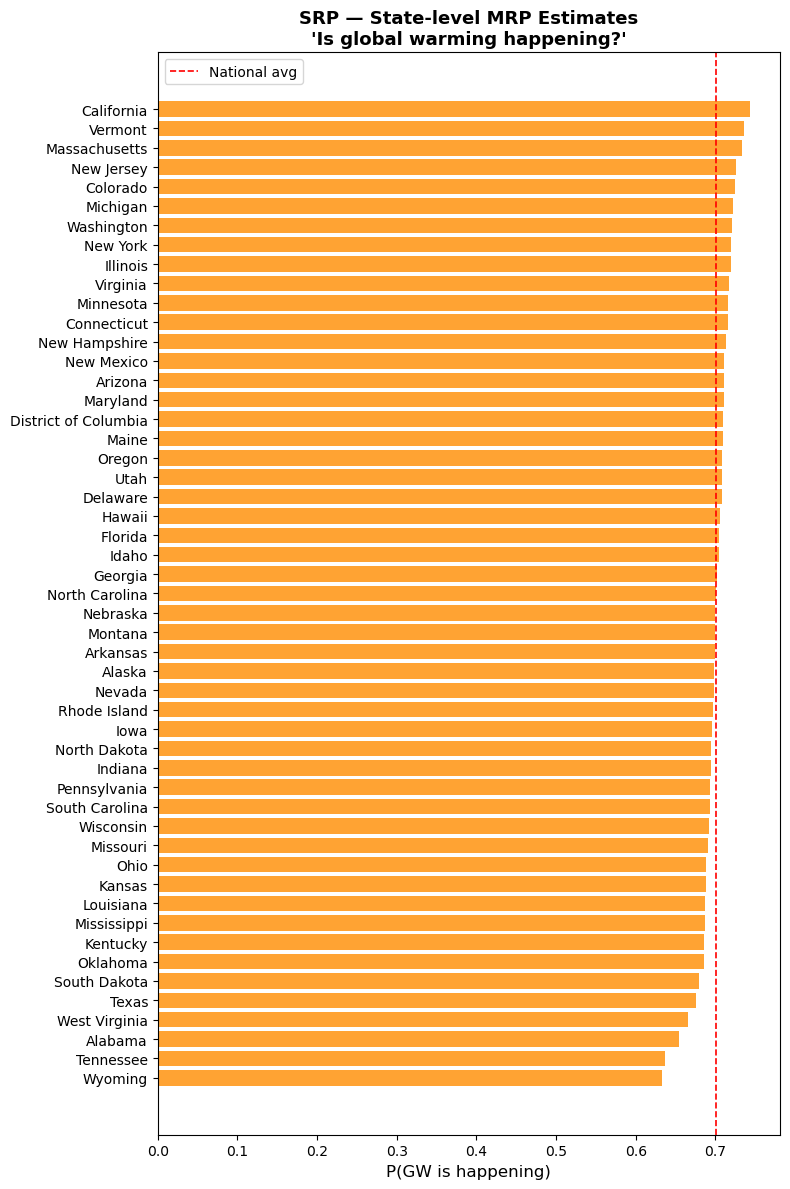

In [8]:
fig, ax = plt.subplots(figsize=(8, 12))
plot_df = result.sort_values("happening_estimate")
ax.barh(plot_df["state_name"], plot_df["happening_estimate"], color="darkorange", alpha=0.8)
ax.axvline(np.average(result["happening_estimate"]), color="red",
           linestyle="--", linewidth=1.2, label="National avg")
ax.set_xlabel("P(GW is happening)", fontsize=12)
ax.set_title("SRP — State-level MRP Estimates\n'Is global warming happening?'",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### 8. Save results

In [ ]:
OUT = "/Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/outputs/estimates/srp_state_estimates.csv"
result[["state_fips","state_name","happening_estimate"]].rename(columns={"happening_estimate":"estimate"}).to_csv(OUT, index=False)
print(f"Saved → {OUT}")
print(result[["state_fips","state_name","happening_estimate"]].to_string(index=False))